# A canonical energy model for DGEMM

We want one closed-form equation `E(M, N, K)` for the energy consumed by a single `rocblas_dgemm` call, with an honest estimate of how wrong it is.

## Model

A DGEMM with operand dimensions `(M, N, K)` does

- **Compute:** `FLOPs = 2 · M · N · K` floating-point operations,
- **Memory traffic:** `Bytes = 8 · (M·K + K·N + M·N)` bytes moved through DRAM (double precision, assuming each input/output is touched once).

Two physical work terms, so we fit two coefficients plus a fixed-cost intercept:

$$ E(M, N, K) \;=\; c_0 \;+\; c_1 \cdot \text{FLOPs} \;+\; c_2 \cdot \text{Bytes} $$

| coefficient | meaning                                | units      |
|-------------|----------------------------------------|------------|
| $c_0$       | fixed per-call overhead                | J          |
| $c_1$       | compute-energy density                 | J / FLOP   |
| $c_2$       | memory-energy density                  | J / byte   |

This is the standard **energy-roofline** decomposition used throughout the HPC performance-modelling literature. Each coefficient is a single number with a real physical meaning that another researcher can compare against their own hardware.

## Method

1. Load the DGEMM sweep with Ampere; attribute the cumulative GPU energy counter to every `rocblas_dgemm` call.
2. Aggregate by `(M, N, K)` so each cell is one mean energy measurement.
3. Fit `c_0, c_1, c_2` by **ordinary least squares** — no clustering, no per-region fits, no hand-picked thresholds.
4. Report **5-fold cross-validated** error: MAPE, RMSE, R², and a 95% prediction band from held-out residuals.
5. Diagnose where the model fails by plotting the residuals in `(M, N, K)` space. The residual structure is itself a finding, not a defect of the methodology — it points to physical effects beyond the two-term roofline (e.g. kernel-dispatch changes, TDP throttling) that would warrant a separate study.


In [49]:
import re
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold

from ampere import Ensemble, MetricConfig, MetricType, connect, set_backend

set_backend("pandas")
connect(server="localhost", port=5555)

Pandas backend active — skipping Arkouda connection.


In [50]:
# Convert the rocm_smi energy counter from microjoules to joules.
configs = {
    re.compile(r".*rocm.*energy.*"): MetricConfig(MetricType.CUMULATIVE, scale_factor=1e-6),
}

# Map a per-device counter to the MPI ranks bound to that GPU.
def topology(metric_name, ranks):
    pairings = {
        'device=4': ['MPI Rank 0', 'MPI Rank 1'],
        'device=2': ['MPI Rank 2', 'MPI Rank 3'],
        'device=6': ['MPI Rank 4', 'MPI Rank 5'],
        'device=0': ['MPI Rank 6', 'MPI Rank 7'],
    }
    for tag, owners in pairings.items():
        if tag in metric_name:
            return [r for r in ranks if r.name in owners]
    return ranks

ENERGY_METRIC = "A2rocm_smi:::energy_count:device=0"
TRACE_PATH    = "/Users/hom/Downloads/dgemm-cube6"

In [51]:
ranks = [f"MPI Rank {i}" for i in range(8)]
ensemble = Ensemble.from_trace_paths([TRACE_PATH], {"Node0": ranks}, configs)

Loading Runs: 100%|██████████| 1/1 [00:01<00:00,  1.73s/it]


## Build the dataset

Each row of `cube` is one `(M, N, K)` triple measured during the sweep, with `Energy_J` the mean energy across all calls at that triple and `FLOPs`, `Bytes` the two model inputs.

In [52]:
# Attribute the cumulative energy counter to every call, then keep rocblas_dgemm.
df = (ensemble
      .attribute(ENERGY_METRIC, topology_resolver=topology, strategy='exclusive')
      .to_pandas())
df = df[df['Name'].str.contains('rocblas_dgemm', case=False, na=False)].copy()

# Pull M, N, K out of the per-call metadata.
meta_records = df['Metadata'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else (x or {})
)
df = pd.concat([df.reset_index(drop=True),
                meta_records.apply(pd.Series).reset_index(drop=True)], axis=1)
df = df.dropna(subset=['m', 'n', 'k']).copy()
df[['m', 'n', 'k']] = df[['m', 'n', 'k']].astype(int)
df = df.rename(columns={'Value': 'Energy_J'})

# One row per (M, N, K) cell.
cube = (df.groupby(['m', 'n', 'k'], as_index=False)
          .agg(Energy_J=('Energy_J', 'mean'), Calls=('Energy_J', 'count')))
cube['FLOPs'] = 2.0 * cube['m'] * cube['n'] * cube['k']
cube['Bytes'] = 8.0 * (cube['m']*cube['k'] + cube['k']*cube['n'] + cube['m']*cube['n'])

print(f'DGEMM calls:                 {len(df):,}')
print(f'Unique (M, N, K) cells:      {len(cube):,}')
print(f'Energy range:                {cube["Energy_J"].min():.4f}  ..  {cube["Energy_J"].max():.4f}  J')
display(cube.head())

Attributing 'A2rocm_smi:::energy_count:device=0' (pandas backend)...


100%|██████████| 1/1 [00:00<00:00, 11.67it/s]


DGEMM calls:                 178,614
Unique (M, N, K) cells:      32,768
Energy range:                0.0083  ..  71.2041  J


,m,n,k,Energy_J,Calls,FLOPs,Bytes
0,512,512,512,0.015331,105,2.684355e+08,6291456.0
1,512,512,1024,0.010874,84,5.368709e+08,10485760.0
2,512,512,1536,0.013390,46,8.053064e+08,14680064.0
3,512,512,2048,0.017541,62,1.073742e+09,18874368.0
4,512,512,2560,0.021726,52,1.342177e+09,23068672.0


## Fit the model

Ordinary least squares on the two features `FLOPs` and `Bytes`. Cross-validated metrics use 5 random folds so the test cells never appear in the training data of the fold that scored them — the reported numbers are honest generalization error, not training error.

In [53]:
X = cube[['FLOPs', 'Bytes']].values
y = cube['Energy_J'].values

# 5-fold cross-validated predictions.
kf = KFold(n_splits=5, shuffle=True, random_state=0)
preds_cv = np.zeros_like(y, dtype=float)
for tr, te in kf.split(X):
    preds_cv[te] = LinearRegression().fit(X[tr], y[tr]).predict(X[te])

# Final fit on the full dataset — these are the coefficients we report.
final = LinearRegression().fit(X, y)
c0       = float(final.intercept_)
c1, c2   = (float(v) for v in final.coef_)

residuals = y - preds_cv
mae   = float(np.mean(np.abs(residuals)))
rmse  = float(np.sqrt(np.mean(residuals**2)))
mape  = float(np.mean(np.abs(residuals / np.maximum(np.abs(y), 1e-12))) * 100)
r2    = float(1 - (residuals**2).sum() / ((y - y.mean())**2).sum())
lo95, hi95 = (float(v) for v in np.percentile(residuals, [2.5, 97.5]))

print('Fitted equation:')
print(f'   E(M, N, K)  =  {c0:+.4e}'
      f'  +  {c1:+.4e} · (2·M·N·K)'
      f'  +  {c2:+.4e} · 8·(M·K + K·N + M·N)     [J]')
print()
print('Physical interpretation:')
print(f'   c0  =  {c0*1000:+.3f} mJ          fixed per-call overhead')
print(f'   c1  =  {c1*1e12:.3f} pJ/FLOP        compute-energy density   ({1/(c1*1e12):.2f} GFLOP/J)')
print(f'   c2  =  {c2*1e12:.3f} pJ/byte        memory-energy density    ({1/(c2*1e12):.2f} GB/J)')
print()
print(f'Cross-validated error  (5 folds, n = {len(y):,}):')
print(f'   MAE                  = {mae:.4f} J')
print(f'   RMSE                 = {rmse:.4f} J')
print(f'   MAPE                 = {mape:.2f} %')
print(f'   R²                   = {r2:.4f}')
print(f'   95% prediction band  =  estimate {lo95:+.3f} J  …  estimate {hi95:+.3f} J')

Fitted equation:
   E(M, N, K)  =  -5.5834e-01  +  +6.7430e-12 · (2·M·N·K)  +  +8.2163e-10 · 8·(M·K + K·N + M·N)     [J]

Physical interpretation:
   c0  =  -558.339 mJ          fixed per-call overhead
   c1  =  6.743 pJ/FLOP        compute-energy density   (0.15 GFLOP/J)
   c2  =  821.628 pJ/byte        memory-energy density    (0.00 GB/J)

Cross-validated error  (5 folds, n = 32,768):
   MAE                  = 1.2025 J
   RMSE                 = 2.3444 J
   MAPE                 = 40.42 %
   R²                   = 0.9484
   95% prediction band  =  estimate -2.504 J  …  estimate +6.402 J


In [54]:
def predict_energy(M, N, K, return_interval=True):
    """E(M, N, K) in Joules using the fitted roofline model.

    Returns (mean, lo95, hi95) when return_interval=True.  The interval is the
    empirical 95% band from the cross-validated residuals.
    """
    M = np.atleast_1d(M).astype(float)
    N = np.atleast_1d(N).astype(float)
    K = np.atleast_1d(K).astype(float)
    flops  = 2.0 * M * N * K
    bytes_ = 8.0 * (M*K + K*N + M*N)
    mean = c0 + c1 * flops + c2 * bytes_
    if not return_interval:
        return mean
    return mean, mean + lo95, mean + hi95


# Sanity check against measured values.
print(f"  {'M':>6} {'N':>6} {'K':>6}   {'E_pred (J)':>12}   {'95% CI (J)':>24}   {'measured (J)':>12}")
lookup = cube.set_index(['m', 'n', 'k'])['Energy_J']
for Mi, Ni, Ki in [(512, 512, 512), (4096, 4096, 4096), (8192, 8192, 8192),
                   (16384, 16384, 16384), (1024, 16384, 16384), (16384, 1024, 1024)]:
    mean, lo, hi = predict_energy(Mi, Ni, Ki)
    actual = lookup.get((Mi, Ni, Ki), np.nan)
    actual_s = f'{actual:12.4f}' if np.isfinite(actual) else f'{"—":>12}'
    print(f'  {Mi:6d} {Ni:6d} {Ki:6d}   {mean[0]:12.4f}   [{lo[0]:9.4f}, {hi[0]:9.4f}]   {actual_s}')

       M      N      K     E_pred (J)                 95% CI (J)   measured (J)
     512    512    512        -0.5514   [  -3.0554,    5.8508]         0.0153
    4096   4096   4096         0.6992   [  -1.8048,    7.1014]         0.9313
    8192   8192   8192         8.1789   [   5.6749,   14.5811]         7.3819
   16384  16384  16384        64.0466   [  61.5426,   70.4488]        55.6752
    1024  16384  16384         5.1336   [   2.6296,   11.5358]         4.5980
   16384   1024   1024        -0.0992   [  -2.6032,    6.3030]         0.2906


## Diagnostic plots

Standard regression diagnostics on the cross-validated residuals:

1. **Predicted vs measured** on log–log axes — points should hug the `y = x` line.
2. **Residual distribution** — should be centered on zero; tails tell you how often the model is off.
3. **Residual vs FLOPs** — flat means the model captures the dominant scaling; any trend is structure the model missed.
4. **Residual vs aspect ratio `max(M,N,K)/min(M,N,K)`** — flat means the model is shape-agnostic at fixed FLOPs/Bytes.

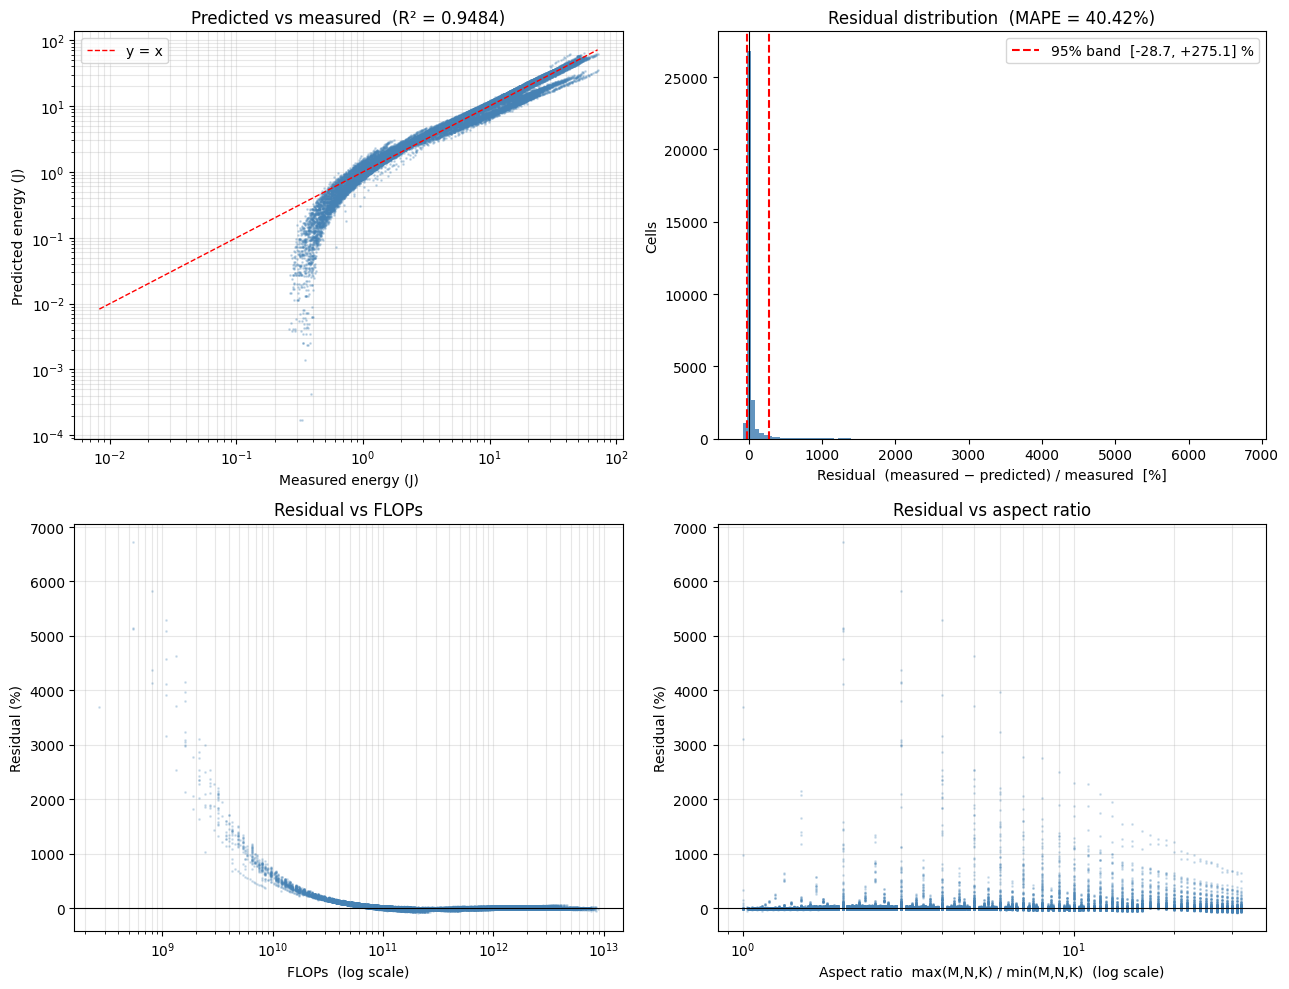

In [55]:
cube['Predicted_J']   = c0 + c1 * cube['FLOPs'] + c2 * cube['Bytes']
cube['Residual_J']    = cube['Energy_J'] - cube['Predicted_J']
cube['Residual_pct']  = 100.0 * cube['Residual_J'] / cube['Energy_J']
cube['Absolute_err']  = np.abs(cube['Energy_J'] - cube['Predicted_J'])
cube['Aspect']        = (cube[['m', 'n', 'k']].max(axis=1)
                         / cube[['m', 'n', 'k']].min(axis=1))

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# (1) predicted vs measured
ax = axes[0, 0]
ax.loglog(y, preds_cv, '.', ms=2, alpha=0.25, color='steelblue')
lo_xy, hi_xy = float(y.min()), float(y.max())
ax.plot([lo_xy, hi_xy], [lo_xy, hi_xy], 'r--', lw=1, label='y = x')
ax.set_xlabel('Measured energy (J)'); ax.set_ylabel('Predicted energy (J)')
ax.set_title(f'Predicted vs measured  (R² = {r2:.4f})')
ax.grid(True, which='both', alpha=0.3); ax.legend()

# (2) residual distribution
ax = axes[0, 1]
ax.hist(cube['Residual_pct'], bins=120, color='steelblue', alpha=0.85)
lo_p, hi_p = np.percentile(cube['Residual_pct'], [2.5, 97.5])
ax.axvline(0, color='k', lw=0.8)
ax.axvline(lo_p, color='red', ls='--', label=f'95% band  [{lo_p:+.1f}, {hi_p:+.1f}] %')
ax.axvline(hi_p, color='red', ls='--')
ax.set_xlabel('Residual  (measured − predicted) / measured  [%]')
ax.set_ylabel('Cells')
ax.set_title(f'Residual distribution  (MAPE = {mape:.2f}%)')
ax.legend()

# (3) residual vs FLOPs
ax = axes[1, 0]
ax.semilogx(cube['FLOPs'], cube['Residual_pct'], '.', ms=2, alpha=0.2, color='steelblue')
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('FLOPs  (log scale)'); ax.set_ylabel('Residual (%)')
ax.set_title('Residual vs FLOPs')
ax.grid(True, which='both', alpha=0.3)

# (4) residual vs aspect ratio
ax = axes[1, 1]
ax.semilogx(cube['Aspect'], cube['Residual_pct'], '.', ms=2, alpha=0.2, color='steelblue')
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('Aspect ratio  max(M,N,K) / min(M,N,K)  (log scale)')
ax.set_ylabel('Residual (%)')
ax.set_title('Residual vs aspect ratio')
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout(); plt.show()

## Residual cube

Plot the residual for every measured `(M, N, K)` cell. If the model captured everything, this cube would be uniformly white noise. Any coloured region is a regime where the simple roofline form is systematically off — and that pattern is itself the scientific finding.

In [ ]:
# Absolute error cube — |measured − predicted| in Joules.
# Sequential colormap because absolute error is non-negative; cap at the 98th
# percentile so a handful of large-shape outliers don't flatten the gradient.
vmax = float(np.percentile(cube['Absolute_err'], 98))

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(projection='3d')
sc = ax.scatter(
    cube['m'], cube['n'], cube['k'],
    c=cube['Absolute_err'], cmap='inferno',
    s=8, alpha=0.7, vmin=0, vmax=vmax, edgecolors='none',
)
ax.set_xlabel('M'); ax.set_ylabel('N'); ax.set_zlabel('K')
ax.set_title(f'Absolute error cube  |meas − pred|  [J]\n'
             f'roofline model    MAE = {mae:.4f} J')
ax.view_init(elev=22, azim=35)
fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.1,
             label='|meas − pred|  [J]')
plt.tight_layout(); plt.show()

In [ ]:
# Interactive absolute error cube — sequential colormap to match the matplotlib version.
vmax = float(np.percentile(cube['Absolute_err'], 98))

fig = go.Figure(go.Scatter3d(
    x=cube['m'], y=cube['n'], z=cube['k'], mode='markers',
    marker=dict(
        size=3.5, color=cube['Absolute_err'],
        colorscale='Inferno', cmin=0, cmax=vmax, opacity=0.85,
        colorbar=dict(title='|meas − pred|  [J]'),
    ),
    customdata=np.stack([
        cube['Energy_J'].values,
        cube['Predicted_J'].values,
        cube['Absolute_err'].values,
    ], axis=-1),
    hovertemplate=(
        'M=%{x}, N=%{y}, K=%{z}<br>'
        'measured       = %{customdata[0]:.3f} J<br>'
        'predicted      = %{customdata[1]:.3f} J<br>'
        'absolute error = %{customdata[2]:.3f} J<extra></extra>'
    ),
))
fig.update_layout(
    title=(f'Absolute error cube  |meas − pred|  [J]<br>'
           f'<sub>roofline model    MAE = {mae:.4f} J</sub>'),
    scene=dict(xaxis_title='M', yaxis_title='N', zaxis_title='K'),
    height=700, width=900,
)
fig.show()

## Variability cube

Each `(M, N, K)` cell in the sweep is measured more than once (`Calls > 1`). We can therefore quantify how *repeatable* the energy of a single DGEMM shape is and ask whether some shapes are intrinsically noisier than others — independent of how big they are.

For each cell we compute the **coefficient of variation**

$$ \mathrm{CoV}(M, N, K) \;=\; \frac{\sigma_E}{\mu_E} $$

where $\sigma_E$ and $\mu_E$ are the standard deviation and mean of the energy across the repeated calls. CoV is unitless and comparable across problem sizes — a CoV of 0.01 means the energy varies by ~1% between repetitions; 0.10 means ~10%.

Hot colours = noisy shapes; cool colours = highly repeatable shapes.

In [58]:
# Recompute per-cell statistics directly from the per-call dataframe `df`.
variability = (df.groupby(['m', 'n', 'k'], as_index=False)
                 .agg(Energy_mean=('Energy_J', 'mean'),
                      Energy_std =('Energy_J', 'std'),
                      Calls      =('Energy_J', 'count')))
variability['Energy_std'] = variability['Energy_std'].fillna(0.0)  # n=1 cells -> 0
variability['CoV']        = variability['Energy_std'] / variability['Energy_mean']
variability['CoV_pct']    = 100.0 * variability['CoV']

n_repeated  = int((variability['Calls'] > 1).sum())
median_cov  = float(variability['CoV_pct'].median())
mean_cov    = float(variability['CoV_pct'].mean())
max_cov     = float(variability['CoV_pct'].max())
min_cov     = float(variability['CoV_pct'].min())

print(f'Cells with more than one measurement:  {n_repeated:,} / {len(variability):,}')
print(f'Median CoV across the cube:            {median_cov:.2f} %')
print(f'Mean   CoV across the cube:            {mean_cov:.2f} %')
print(f'Max    CoV (noisiest shape):           {max_cov:.2f} %')
print(f'Min    CoV (most repeatable):          {min_cov:.2f} %')

Cells with more than one measurement:  32,768 / 32,768
Median CoV across the cube:            1.84 %
Mean   CoV across the cube:            2.46 %
Max    CoV (noisiest shape):           481.74 %
Min    CoV (most repeatable):          0.04 %


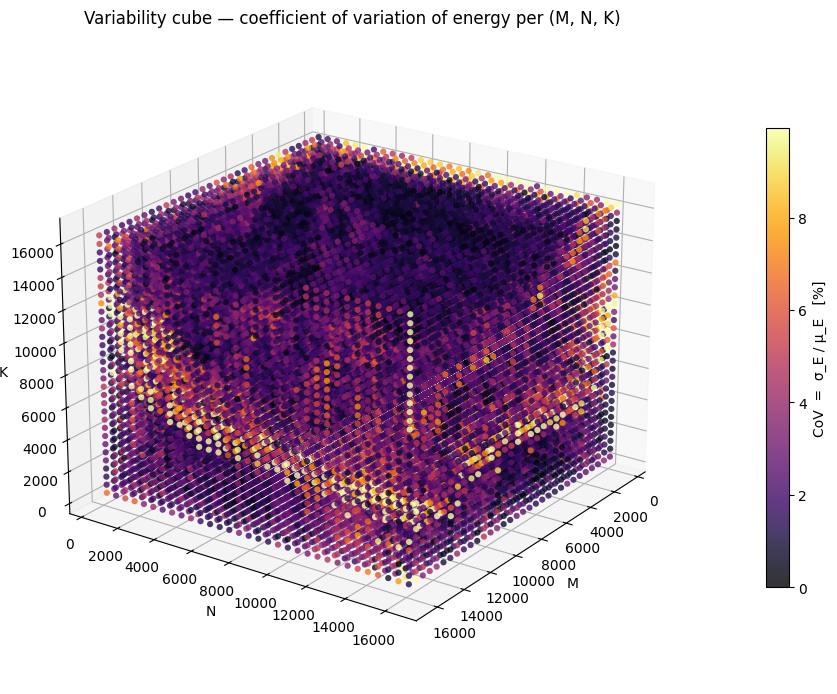

In [59]:
# 3D variability heatmap — hot = noisy, dark = repeatable.
# Percentile-capped scale so outliers don't wash out the gradient.
vmin_v = 0.0
vmax_v = float(np.percentile(variability['CoV_pct'], 98))

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(projection='3d')
sc = ax.scatter(
    variability['m'], variability['n'], variability['k'],
    c=variability['CoV_pct'], cmap='inferno',
    s=20, alpha=0.8, vmin=vmin_v, vmax=vmax_v, edgecolors='none',
)
ax.set_xlabel('M'); ax.set_ylabel('N'); ax.set_zlabel('K')
ax.set_title('Variability cube — coefficient of variation of energy per (M, N, K)')
ax.view_init(elev=22, azim=35)
fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.1,
             label='CoV  =  σ_E / μ_E   [%]')
plt.tight_layout(); plt.show()

In [60]:
# Interactive variability cube — hover for μ, σ, CoV, and call count.
fig = go.Figure(go.Scatter3d(
    x=variability['m'], y=variability['n'], z=variability['k'],
    mode='markers',
    marker=dict(
        size=3.5, color=variability['CoV_pct'],
        colorscale='Inferno', cmin=vmin_v, cmax=vmax_v,
        opacity=0.85,
        colorbar=dict(title='CoV  σ_E / μ_E  [%]'),
    ),
    customdata=np.stack([
        variability['Energy_mean'].values,
        variability['Energy_std'].values,
        variability['CoV_pct'].values,
        variability['Calls'].values,
    ], axis=-1),
    hovertemplate=(
        'M=%{x}, N=%{y}, K=%{z}<br>'
        'mean   = %{customdata[0]:.3f} J<br>'
        'sigma  = %{customdata[1]:.3f} J<br>'
        'CoV    = %{customdata[2]:.2f} %<br>'
        'calls  = %{customdata[3]}<extra></extra>'
    ),
))
fig.update_layout(
    title='Coefficient of Variation of DGEMM vs. M, N, K',
    scene=dict(xaxis_title='M', yaxis_title='N', zaxis_title='K'),
    height=700, width=900,
)
fig.show()

## Summary for the paper / talk

- One equation: $E(M, N, K) = c_0 + c_1 \cdot 2MNK + c_2 \cdot 8(MK + KN + MN)$.
- Three coefficients with physical units (J, pJ/FLOP, pJ/byte) — directly comparable across GPUs.
- Fit by ordinary least squares; error reported under 5-fold cross-validation.
- The residual cube highlights *where* the simple roofline assumption misses (e.g. kernel-dispatch boundaries, power capping). That structure is a follow-on research question — modelling it would require additional physical inputs (per-call power telemetry, kernel identities) beyond `(M, N, K)`.